In [13]:
# ============================================================
#  Configuration — 비교할 런 디렉토리 목록
# ============================================================
RESULTS_DIR = "results"

RUN_NAMES = [
    "20260411_145417_G_H100_80GB_HBM3_x4_Qwen2.5-32B-Instruct",
    "20260411_145805_H_C_H100_80GB_HBM3_x4_Qwen2.5-32B-Instruct"
]

In [14]:
# ============================================================
#  Load runs
# ============================================================
import json, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# ── Seaborn global theme ────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#cccccc',
})

# ── Color palette (bar / line) ──────────────────────────────
PALETTE = {
    'GPU-only':  '#C27900',   # deep amber
    'cpu-first': '#1D4ED8',   # deep blue
    'gpu-first': '#15803D',   # forest green
    'RR':        '#BE185D',   # deep rose
    'other':     '#4B5563',   # slate gray
}

# ── Per-run colormaps for heatmaps ──────────────────────────
def _cmap(name, light, dark):
    return LinearSegmentedColormap.from_list(name, [light, dark])

CMAPS = {
    'GPU-only':  _cmap('amber', '#FFFBEB', '#C27900'),
    'cpu-first': _cmap('blue',  '#EFF6FF', '#1D4ED8'),
    'gpu-first': _cmap('green', '#F0FDF4', '#15803D'),
    'RR':        _cmap('rose',  '#FDF2F8', '#BE185D'),
    'other':     _cmap('gray',  '#F9FAFB', '#4B5563'),
}

results_path = Path(RESULTS_DIR)

def load_run(run_dir):
    run = {'dir': run_dir, 'name': run_dir.name}
    for mode in ('hybrid', 'gpu_only'):
        jf = run_dir / f'{mode}.json'
        if jf.exists():
            with open(jf) as f: run['bench'] = json.load(f)
            run['mode'] = mode
            break
    if 'bench' not in run: return None
    si_path = run_dir / 'system_info.json'
    if si_path.exists():
        with open(si_path) as f: run['sysinfo'] = json.load(f)
    else:
        run['sysinfo'] = {}
    for mtype in ('gpu', 'cpu'):
        csv_path = run_dir / f"{run['mode']}_monitor_{mtype}.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            if 'elapsed_s' in df.columns:
                df['elapsed_s'] = df['elapsed_s'] - df['elapsed_s'].iloc[0]
            run[f'{mtype}_csv'] = df
        else:
            run[f'{mtype}_csv'] = None
    return run

def make_label(run):
    hc = run.get('sysinfo', {}).get('hybrid_config', {})
    mode = run.get('mode', '?')
    model = run['bench'].get('model_id', '?').split('/')[-1]
    if mode == 'gpu_only':
        return f'GPU-only | {model}'
    s = hc.get('routing_strategy', '?')
    p = hc.get('routing_priority', '?')
    seqs = hc.get('cpu_max_seqs', '?')
    routing = 'RR' if s == 'round-robin' else f'{s}({p})'
    return f'Hybrid {routing} seqs={seqs} | {model}'

def run_color_key(r):
    l = make_label(r)
    if 'GPU-only' in l: return 'GPU-only'
    if 'cpu-first' in l: return 'cpu-first'
    if 'gpu-first' in l: return 'gpu-first'
    if 'RR' in l: return 'RR'
    return 'other'

runs = []
for name in RUN_NAMES:
    d = results_path / name
    if not d.is_dir():
        print(f'[WARN] Not found: {d}')
        continue
    r = load_run(d)
    if r:
        runs.append(r)
    else:
        print(f'[WARN] No benchmark JSON: {d}')

print(f'Loaded {len(runs)} runs')
for i, r in enumerate(runs):
    print(f'  [{i}] {make_label(r)}  —  {r["name"]}')

Loaded 2 runs
  [0] GPU-only | Qwen2.5-32B-Instruct  —  20260411_145417_G_H100_80GB_HBM3_x4_Qwen2.5-32B-Instruct
  [1] Hybrid throughput-adaptive(cpu-first) seqs=0 | Qwen2.5-32B-Instruct  —  20260411_145805_H_C_H100_80GB_HBM3_x4_Qwen2.5-32B-Instruct


In [15]:
# ============================================================
#  Section 1: Summary Table
# ============================================================

rows = []
for i, r in enumerate(runs):
    b = r['bench']
    si = r.get('sysinfo', {})
    gpu_devs = si.get('gpu', {}).get('devices', [{}])
    gpu_name = gpu_devs[0].get('name', '-') if gpu_devs else '-'

    # Power efficiency
    mon = r.get('gpu_csv')
    avg_power = None
    tok_per_w = '-'
    tok_per_wh = '-'
    if mon is not None and 'gpu_avg_power_w' in mon.columns:
        avg_power = mon['gpu_avg_power_w'].mean()
        tok = b.get('output_throughput', 0)
        if avg_power > 0 and tok > 0:
            tok_per_w = f"{tok / avg_power:.1f}"
            dur = b.get('duration', 0)
            total_tokens = b.get('total_output_tokens', 0)
            energy_wh = avg_power * dur / 3600
            tok_per_wh = f"{total_tokens / energy_wh:.0f}" if energy_wh > 0 else '-'

    rows.append({
        '#': i,
        'Label': make_label(r),
        'Wall (s)': round(b.get('wall_time_s', 0), 1) if b.get('wall_time_s') else '-',
        'Duration (s)': round(b.get('duration', 0), 1),
        'Req/s': round(b.get('request_throughput', 0), 2),
        'Tok/s': round(b.get('output_throughput', 0), 0),
        'TTFT (ms)': round(b.get('mean_ttft_ms', 0), 0),
        'TPOT (ms)': round(b.get('mean_tpot_ms', 0), 2),
        'Avg W': f"{avg_power:.0f}" if avg_power else '-',
        'Tok/s/W': tok_per_w,
        'Tok/Wh': tok_per_wh,
        'Completed': f"{b.get('completed','?')}/{b.get('num_prompts','?')}",
        'GPU': gpu_name,
    })

summary_df = pd.DataFrame(rows).set_index('#')

def color_rows(row):
    label = row.get('Label', '')
    if 'GPU-only' in label:
        return ['background-color: #fffde7'] * len(row)
    elif 'cpu-first' in label:
        return ['background-color: #e3f2fd'] * len(row)
    elif 'gpu-first' in label:
        return ['background-color: #e8f5e9'] * len(row)
    elif 'RR' in label:
        return ['background-color: #fce4ec'] * len(row)
    return ['background-color: #f5f5f5'] * len(row)

display(summary_df.style.apply(color_rows, axis=1)
        .set_table_styles([
            {'selector':'th','props':[('background-color','#2d4a7a'),('color','white'),('font-size','12px'),('padding','5px 10px')]},
        ])
        .set_caption('<b>All Runs Summary</b> — yellow=GPU-only, blue=cpu-first, green=gpu-first, pink=RR'))

,Label,Wall (s),Duration (s),Req/s,Tok/s,TTFT (ms),TPOT (ms),Avg W,Tok/s/W,Tok/Wh,Completed,GPU
#,,,,,,,,,,,,
0,GPU-only | Qwen2.5-32B-Instruct,17.400000,7.000000,71.360000,8774.000000,1746.000000,41.820000,1281,6.8,24654,500/500,NVIDIA H100 80GB HBM3
1,Hybrid throughput-adaptive(cpu-first) seqs=0 | Qwen2.5-32B-Instruct,17.200000,7.100000,70.470000,8674.000000,1802.000000,41.930000,1302,6.7,23985,500/500,NVIDIA H100 80GB HBM3


In [16]:
# ============================================================
#  Section 2: vs [0] Comparison
# ============================================================

if len(runs) >= 2:
    METRICS = [
        ('wall_time_s',            'Wall Time (s)',     'lower',  '.1f'),
        ('request_throughput',     'Req/s',             'higher', '.2f'),
        ('output_throughput',      'Tok/s',             'higher', '.0f'),
        ('duration',               'Duration (s)',      'lower',  '.1f'),
        ('mean_ttft_ms',           'Mean TTFT (ms)',    'lower',  '.1f'),
        ('p99_ttft_ms',            'P99 TTFT (ms)',     'lower',  '.1f'),
        ('mean_tpot_ms',           'Mean TPOT (ms)',    'lower',  '.2f'),
        ('p99_tpot_ms',            'P99 TPOT (ms)',     'lower',  '.2f'),
    ]

    base = runs[0]['bench']
    print(f'Base [0]: {make_label(runs[0])}\n')

    for i in range(1, len(runs)):
        comp = runs[i]['bench']
        diff_rows = []
        for key, label, direction, fmt in METRICS:
            bv = base.get(key)
            cv = comp.get(key)
            if bv is None or cv is None or bv == 0: continue
            diff_pct = (cv - bv) / abs(bv) * 100
            if direction == 'higher':
                marker = '▲' if diff_pct > 1 else ('▼' if diff_pct < -1 else '~')
            else:
                marker = '▼' if diff_pct > 1 else ('▲' if diff_pct < -1 else '~')
            diff_rows.append({
                'Metric': label,
                '[0]': format(bv, fmt),
                f'[{i}]': format(cv, fmt),
                'Diff': f'{diff_pct:+.1f}%',
                '': marker,
            })
        if diff_rows:
            df = pd.DataFrame(diff_rows).set_index('Metric')
            def highlight_diff(val):
                if '▲' in str(val): return 'color: green; font-weight: bold'
                if '▼' in str(val): return 'color: red; font-weight: bold'
                return ''
            display(df.style.applymap(highlight_diff, subset=[''])
                    .set_caption(f'<b>[{i}] {make_label(runs[i])} vs [0]</b>'))
else:
    print('Need >= 2 runs for comparison')

Base [0]: GPU-only | Qwen2.5-32B-Instruct



,[0],[1],Diff,
Metric,,,,
Wall Time (s),17.4,17.2,-0.8%,~
Req/s,71.36,70.47,-1.2%,▼
Tok/s,8774,8674,-1.1%,▼
Duration (s),7.0,7.1,+1.3%,▼
Mean TTFT (ms),1746.0,1802.2,+3.2%,▼
P99 TTFT (ms),2897.3,2973.8,+2.6%,▼
Mean TPOT (ms),41.82,41.93,+0.3%,~
P99 TPOT (ms),48.56,48.93,+0.8%,~


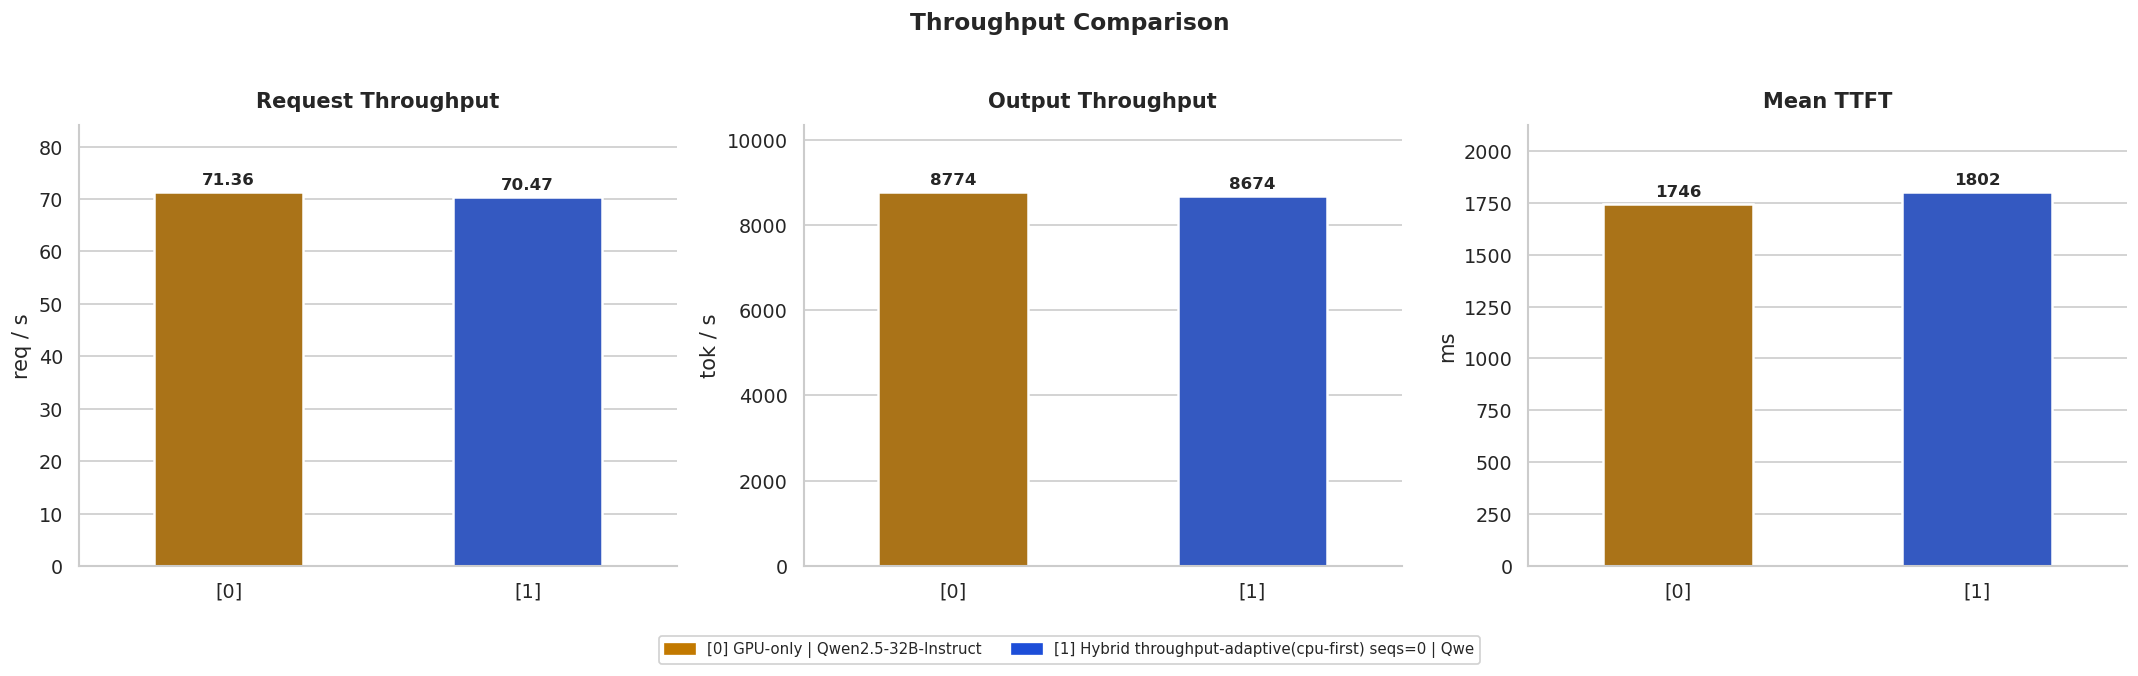

In [17]:
# ============================================================
#  Section 3: Throughput Bar Chart
# ============================================================

labels_short = [f'[{i}]' for i in range(len(runs))]
color_keys   = [run_color_key(r) for r in runs]

METRIC_SPECS = [
    ('request_throughput', 'req / s',  'Request Throughput', '.2f'),
    ('output_throughput',  'tok / s',  'Output Throughput',  '.0f'),
    ('mean_ttft_ms',       'ms',       'Mean TTFT',          '.0f'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Throughput Comparison', fontsize=14, fontweight='bold', y=1.02)

for ax, (key, unit, title, fmt) in zip(axes, METRIC_SPECS):
    vals = [r['bench'].get(key, 0) for r in runs]
    df = pd.DataFrame({'Run': labels_short, 'Value': vals, 'Color': color_keys})
    palette = {k: PALETTE[k] for k in set(color_keys)}
    sns.barplot(data=df, x='Run', y='Value', hue='Color', palette=palette,
                dodge=False, ax=ax, width=0.5, edgecolor='white', linewidth=1.5, legend=False)

    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel(unit)

    max_v = max(vals) if max(vals) > 0 else 1
    for bar, v in zip(ax.patches, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max_v * 0.012,
                    format(v, fmt), ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
    ax.set_ylim(0, max_v * 1.18)

patches = [mpatches.Patch(color=PALETTE[run_color_key(r)], label=f'[{i}] {make_label(r)[:50]}')
           for i, r in enumerate(runs)]
fig.legend(handles=patches, loc='lower center', ncol=min(3, len(runs)),
           fontsize=9, bbox_to_anchor=(0.5, -0.08), framealpha=0.9)
plt.tight_layout()
plt.show()

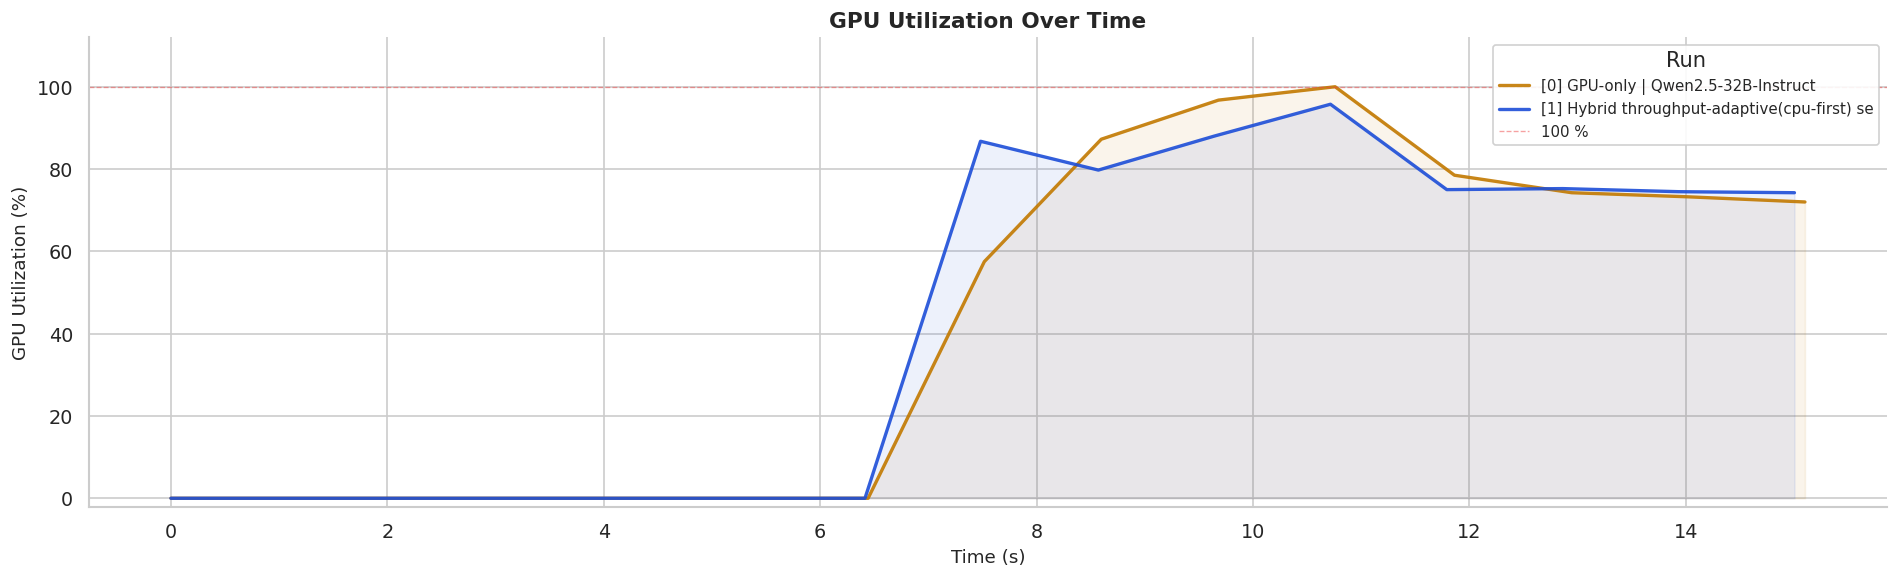

In [18]:
# ============================================================
#  Section 4: GPU Utilization Comparison
# ============================================================

dfs = []
for i, r in enumerate(runs):
    csv = r.get('gpu_csv')
    if csv is not None and 'gpu_avg_util_pct' in csv.columns:
        tmp = csv[['elapsed_s', 'gpu_avg_util_pct']].copy()
        tmp['Run'] = f'[{i}] {make_label(r)[:40]}'
        tmp['_ck'] = run_color_key(r)
        dfs.append(tmp)

fig, ax = plt.subplots(figsize=(16, 5))

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    line_palette = {df['Run'].iloc[0]: PALETTE[df['_ck'].iloc[0]] for df in dfs}

    sns.lineplot(data=df_all, x='elapsed_s', y='gpu_avg_util_pct',
                 hue='Run', palette=line_palette, ax=ax, lw=2, alpha=0.9)

    for df in dfs:
        color = line_palette[df['Run'].iloc[0]]
        ax.fill_between(df['elapsed_s'], df['gpu_avg_util_pct'], alpha=0.08, color=color)

    ax.axhline(100, color='#ef4444', linestyle='--', lw=0.8, alpha=0.5, label='100 %')
    ax.set_ylim(-2, 112)
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('GPU Utilization (%)', fontsize=11)
    ax.set_title('GPU Utilization Over Time', fontsize=13, fontweight='bold')
    ax.legend(title='Run', fontsize=9, loc='upper right', framealpha=0.9)
else:
    ax.text(0.5, 0.5, 'No GPU utilization data', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color='gray')
    ax.set_title('GPU Utilization — No Data', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

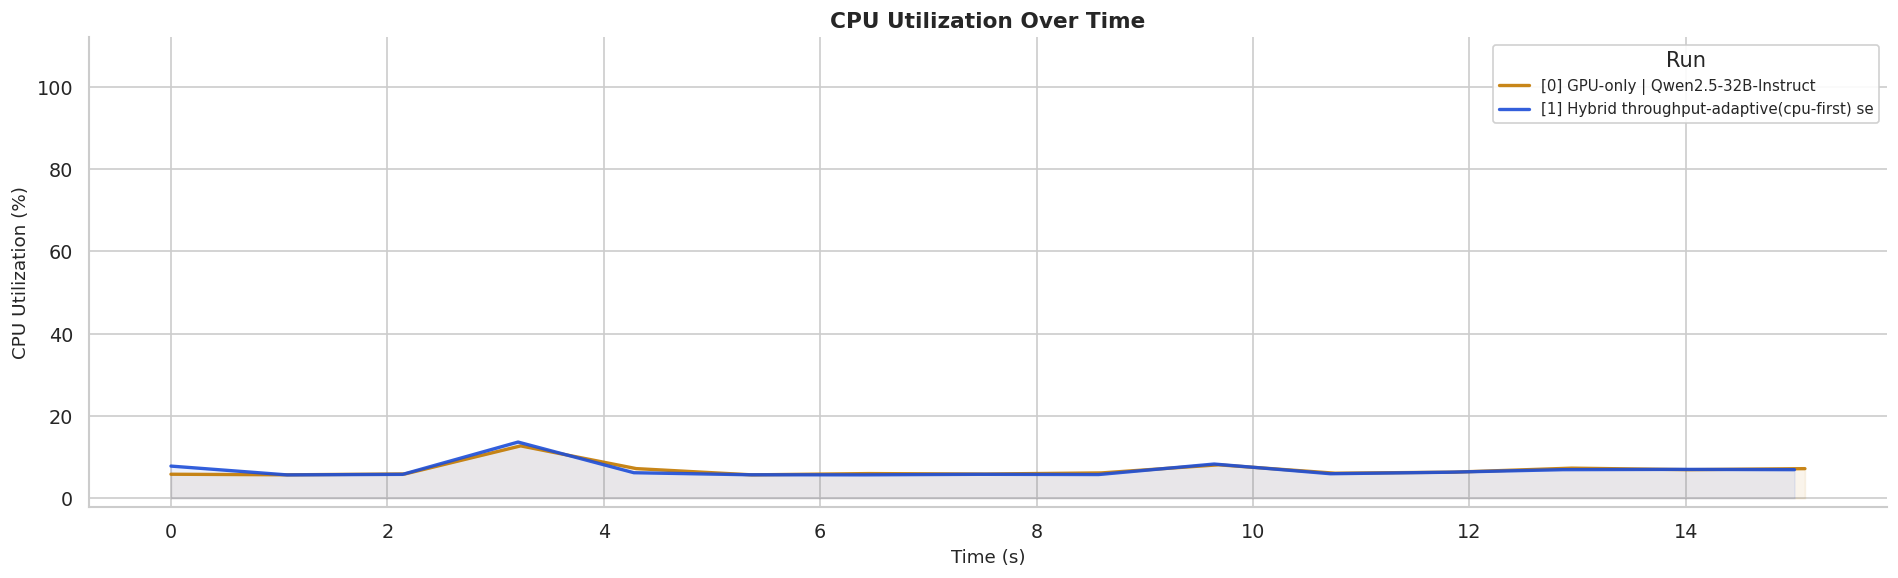

In [19]:
# ============================================================
#  Section 5: CPU Utilization Comparison
# ============================================================

dfs = []
for i, r in enumerate(runs):
    csv = r.get('cpu_csv')
    if csv is not None and 'cpu_avg_util_pct' in csv.columns:
        tmp = csv[['elapsed_s', 'cpu_avg_util_pct']].copy()
        tmp['Run'] = f'[{i}] {make_label(r)[:40]}'
        tmp['_ck'] = run_color_key(r)
        dfs.append(tmp)

fig, ax = plt.subplots(figsize=(16, 5))

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    line_palette = {df['Run'].iloc[0]: PALETTE[df['_ck'].iloc[0]] for df in dfs}

    sns.lineplot(data=df_all, x='elapsed_s', y='cpu_avg_util_pct',
                 hue='Run', palette=line_palette, ax=ax, lw=2, alpha=0.9)

    for df in dfs:
        color = line_palette[df['Run'].iloc[0]]
        ax.fill_between(df['elapsed_s'], df['cpu_avg_util_pct'], alpha=0.08, color=color)

    ax.set_ylim(-2, 112)
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('CPU Utilization (%)', fontsize=11)
    ax.set_title('CPU Utilization Over Time', fontsize=13, fontweight='bold')
    ax.legend(title='Run', fontsize=9, loc='upper right', framealpha=0.9)
else:
    ax.text(0.5, 0.5, 'No CPU utilization data', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color='gray')
    ax.set_title('CPU Utilization — No Data', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

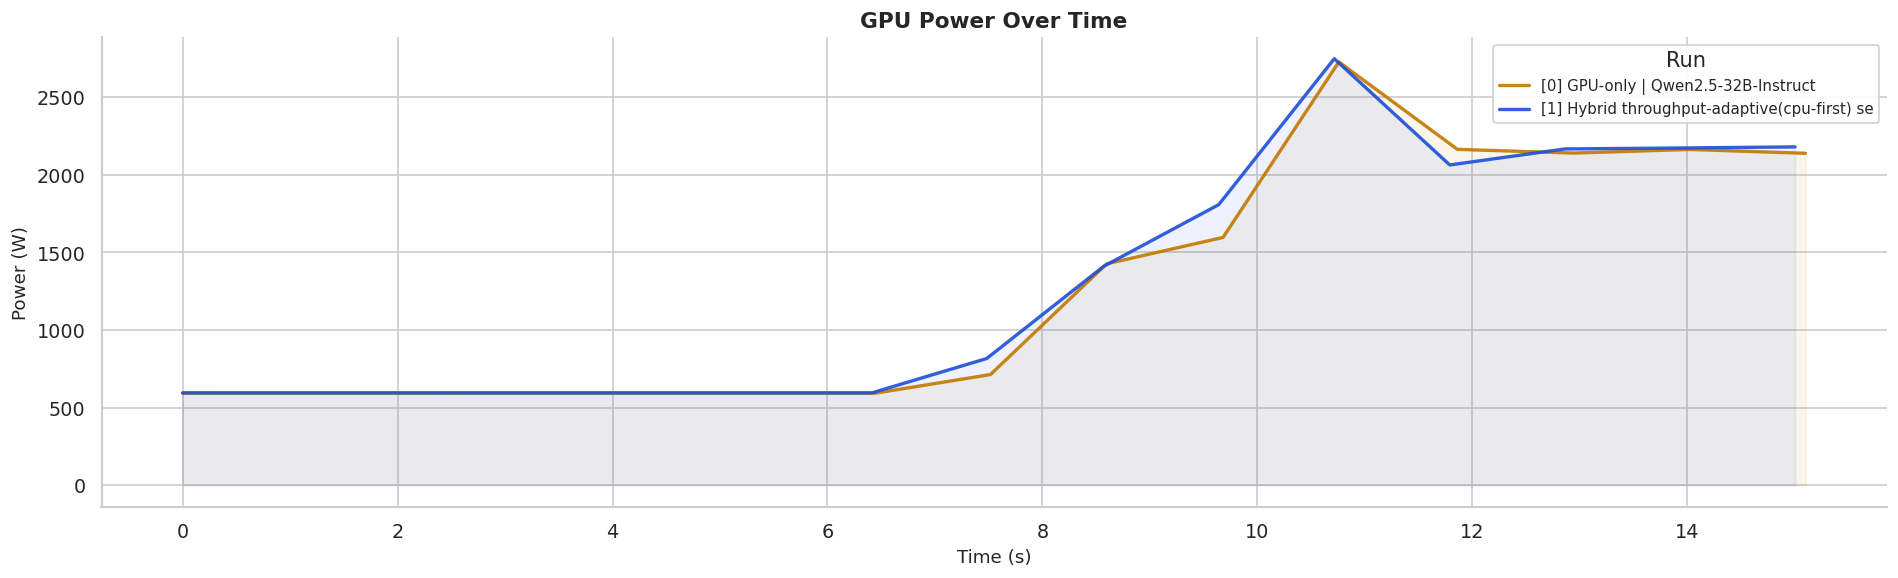

In [20]:
# ============================================================
#  Section 6: GPU Power Comparison
# ============================================================

dfs = []
for i, r in enumerate(runs):
    csv = r.get('gpu_csv')
    if csv is not None and 'gpu_avg_power_w' in csv.columns:
        tmp = csv[['elapsed_s', 'gpu_avg_power_w']].copy()
        tmp['Run'] = f'[{i}] {make_label(r)[:40]}'
        tmp['_ck'] = run_color_key(r)
        dfs.append(tmp)

fig, ax = plt.subplots(figsize=(16, 5))

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    line_palette = {df['Run'].iloc[0]: PALETTE[df['_ck'].iloc[0]] for df in dfs}

    sns.lineplot(data=df_all, x='elapsed_s', y='gpu_avg_power_w',
                 hue='Run', palette=line_palette, ax=ax, lw=2, alpha=0.9)

    for df in dfs:
        color = line_palette[df['Run'].iloc[0]]
        ax.fill_between(df['elapsed_s'], df['gpu_avg_power_w'], alpha=0.07, color=color)

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Power (W)', fontsize=11)
    ax.set_title('GPU Power Over Time', fontsize=13, fontweight='bold')
    ax.legend(title='Run', fontsize=9, loc='upper right', framealpha=0.9)
else:
    ax.text(0.5, 0.5, 'No GPU power data', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color='gray')
    ax.set_title('GPU Power — No Data', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

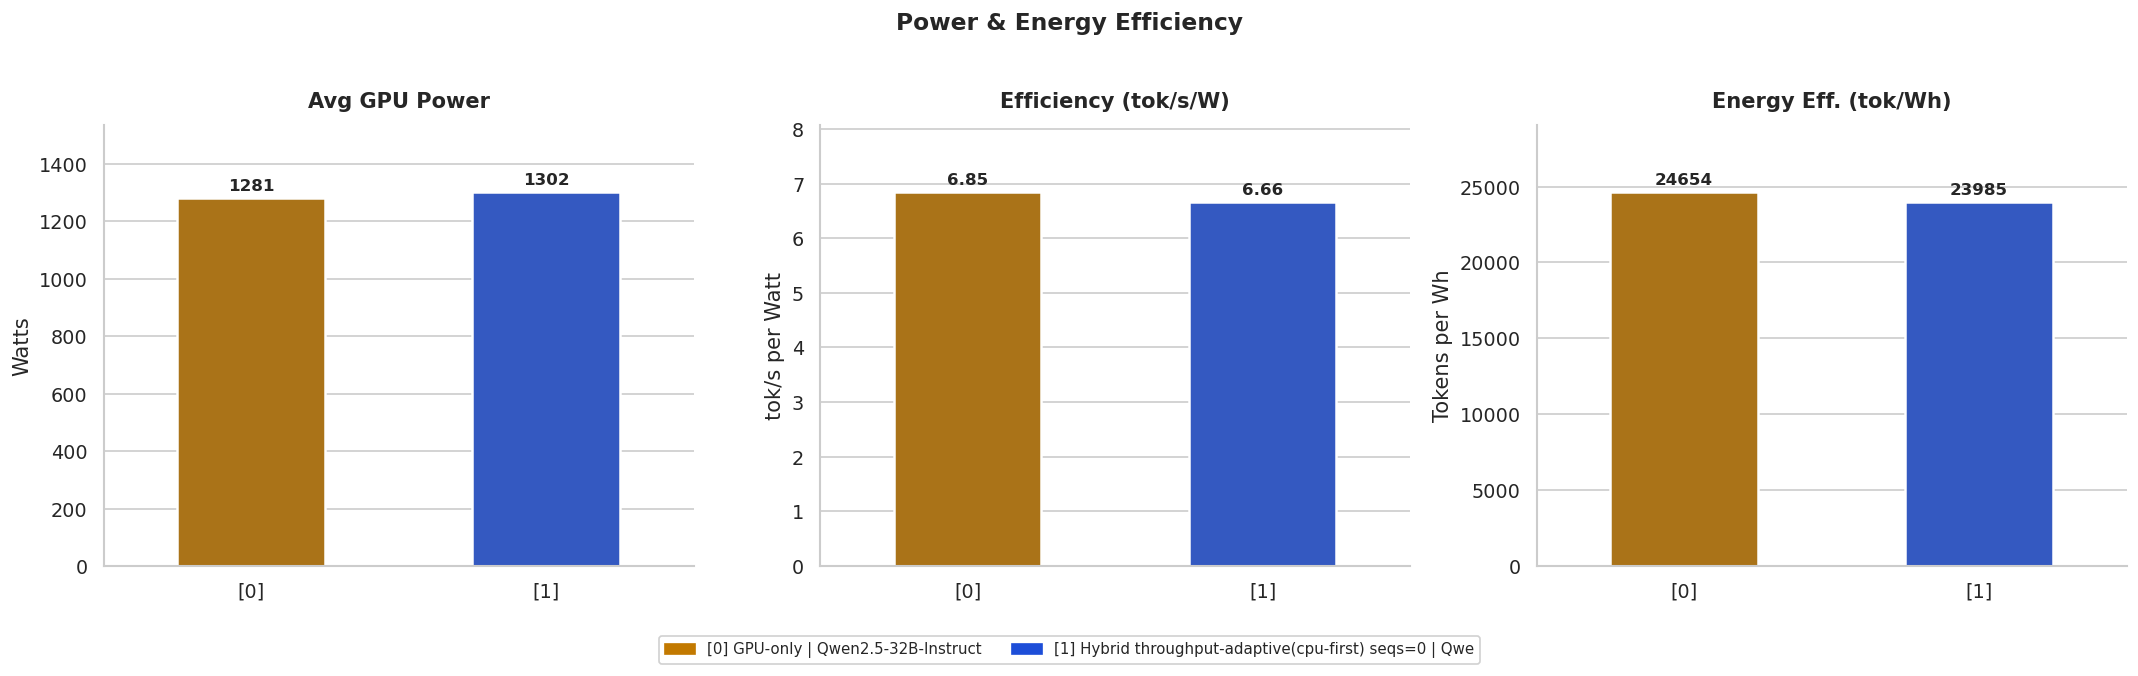

In [21]:
# ============================================================
#  Section 6b: Power Efficiency Comparison
# ============================================================

labels_short = [f'[{i}]' for i in range(len(runs))]
color_keys   = [run_color_key(r) for r in runs]

avg_powers = []
for r in runs:
    csv = r.get('gpu_csv')
    avg_powers.append(
        csv['gpu_avg_power_w'].mean()
        if csv is not None and 'gpu_avg_power_w' in csv.columns else 0
    )

tok_per_w = [
    r['bench'].get('output_throughput', 0) / avg_powers[i] if avg_powers[i] > 0 else 0
    for i, r in enumerate(runs)
]

tok_per_wh = []
for i, r in enumerate(runs):
    b = r['bench']
    dur = b.get('duration', 0)
    total_tokens = b.get('total_output_tokens', 0)
    energy_wh = avg_powers[i] * dur / 3600
    tok_per_wh.append(total_tokens / energy_wh if energy_wh > 0 else 0)

SPEC_LIST = [
    ('Avg GPU Power',         'Watts',          avg_powers, '.0f'),
    ('Efficiency (tok/s/W)',  'tok/s per Watt', tok_per_w,  '.2f'),
    ('Energy Eff. (tok/Wh)', 'Tokens per Wh',  tok_per_wh, '.0f'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Power & Energy Efficiency', fontsize=14, fontweight='bold', y=1.02)

for ax, (title, ylabel, vals, fmt) in zip(axes, SPEC_LIST):
    df = pd.DataFrame({'Run': labels_short, 'Value': vals, 'Color': color_keys})
    palette = {k: PALETTE[k] for k in set(color_keys)}
    sns.barplot(data=df, x='Run', y='Value', hue='Color', palette=palette,
                dodge=False, ax=ax, width=0.5, edgecolor='white', linewidth=1.5, legend=False)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    max_v = max(vals) if max(vals) > 0 else 1
    for bar, v in zip(ax.patches, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max_v * 0.012,
                    format(v, fmt), ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
    ax.set_ylim(0, max_v * 1.18)

patches = [mpatches.Patch(color=PALETTE[run_color_key(r)], label=f'[{i}] {make_label(r)[:50]}')
           for i, r in enumerate(runs)]
fig.legend(handles=patches, loc='lower center', ncol=min(3, len(runs)),
           fontsize=9, bbox_to_anchor=(0.5, -0.08), framealpha=0.9)
plt.tight_layout()
plt.show()

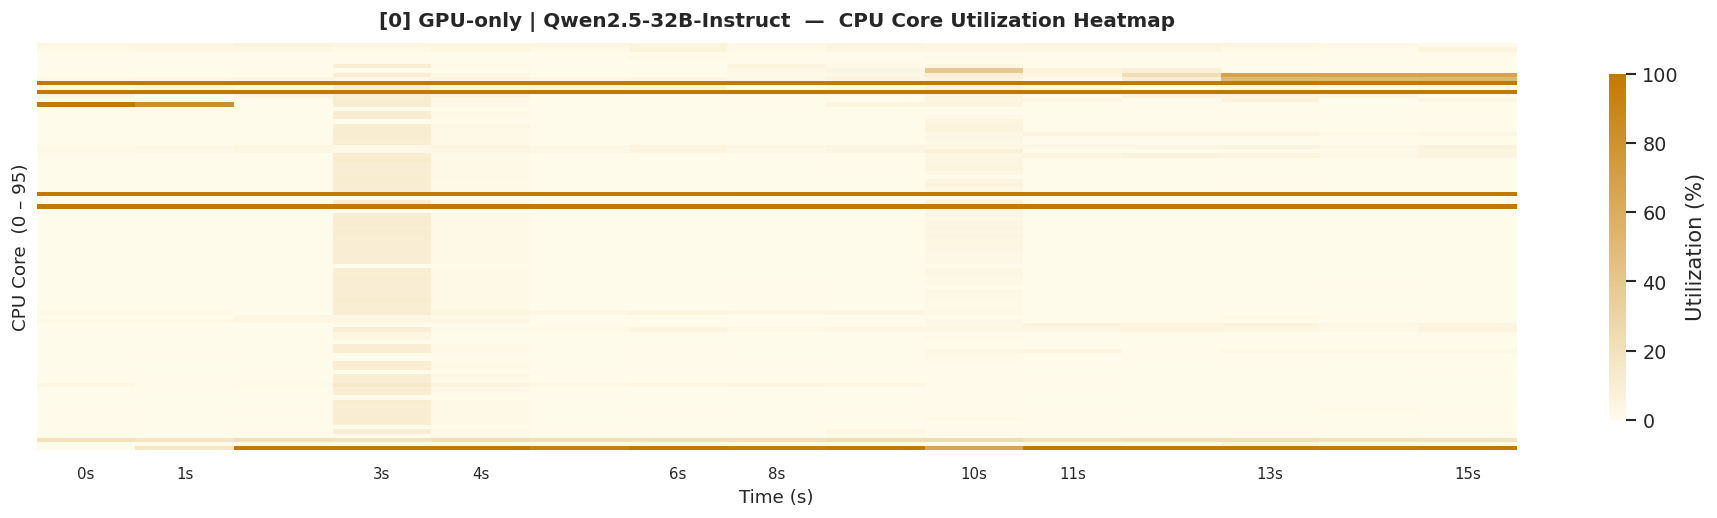

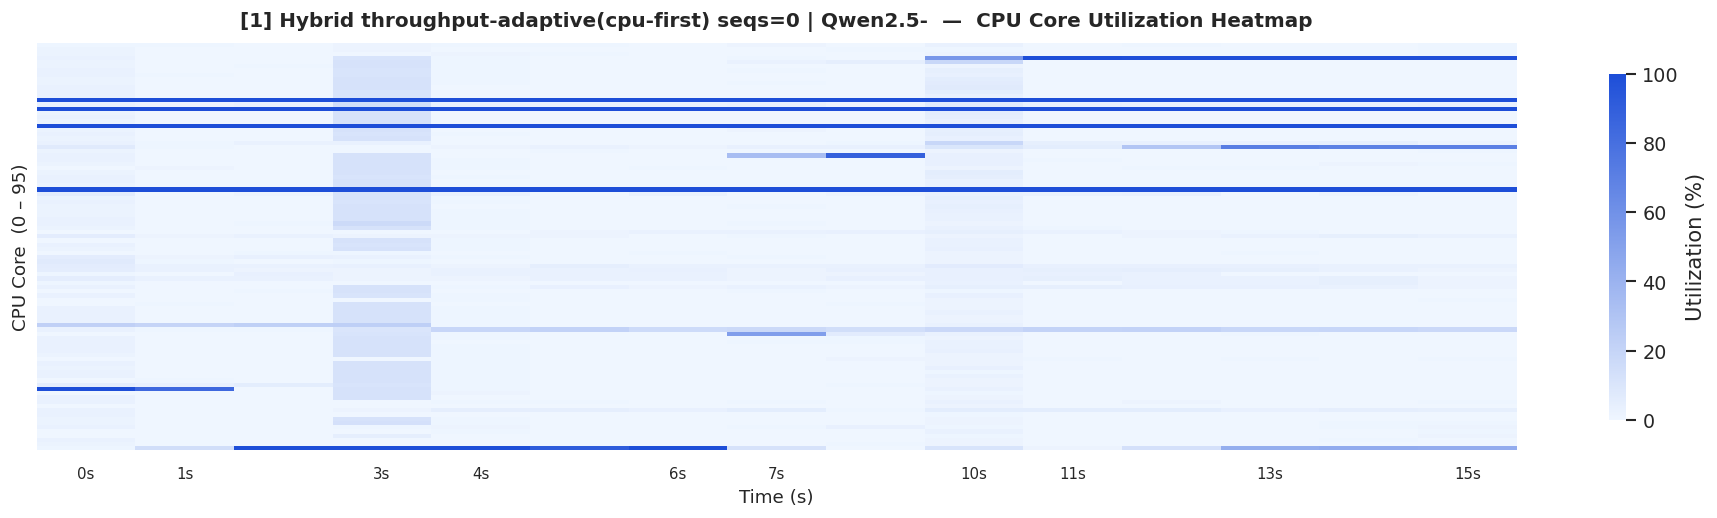

In [22]:
# ============================================================
#  Section 7: Per-Run CPU Heatmaps
# ============================================================

for i, r in enumerate(runs):
    csv = r.get('cpu_csv')
    if csv is None: continue
    core_cols = [c for c in csv.columns if c.startswith('core') and c.endswith('_util_pct')]
    if not core_cols: continue

    n_cores = len(core_cols)
    fig_h = max(1.5, min(4.5, n_cores * 0.09 + 0.75))
    fig, ax = plt.subplots(figsize=(16, fig_h))

    data = csv[core_cols].values.T
    ck = run_color_key(r)

    sns.heatmap(data, ax=ax, cmap=CMAPS[ck], vmin=0, vmax=100,
                xticklabels=False, yticklabels=False,
                cbar_kws={'label': 'Utilization (%)', 'shrink': 0.85},
                linewidths=0, rasterized=True)

    n_samples = data.shape[1]
    tick_count = min(10, n_samples)
    tick_idxs = np.linspace(0, n_samples - 1, tick_count, dtype=int)
    ax.set_xticks(tick_idxs + 0.5)
    ax.set_xticklabels(
        [f'{csv["elapsed_s"].iloc[p]:.0f}s' for p in tick_idxs],
        rotation=0, fontsize=9
    )
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel(f'CPU Core  (0 – {n_cores - 1})', fontsize=11)
    ax.set_title(
        f'[{i}] {make_label(r)[:55]}  —  CPU Core Utilization Heatmap',
        fontsize=12, fontweight='bold', pad=10
    )
    plt.tight_layout()
    plt.show()

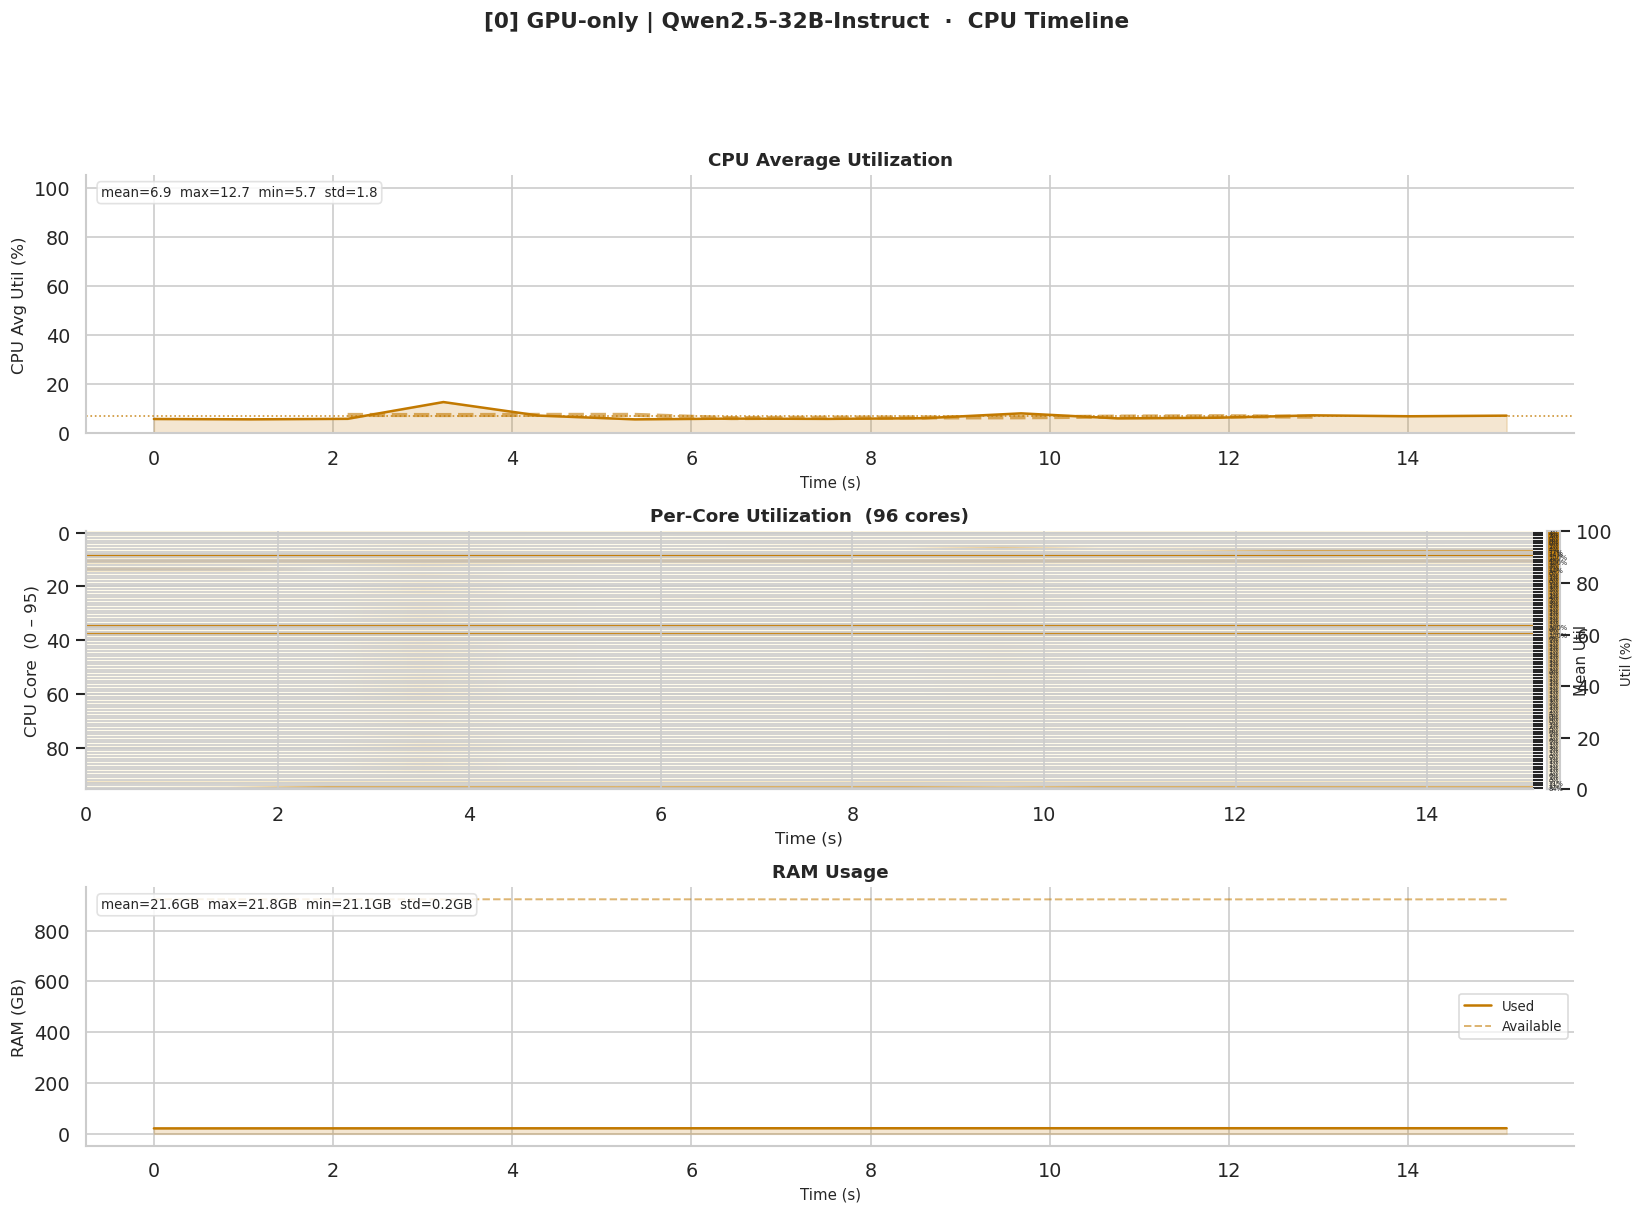

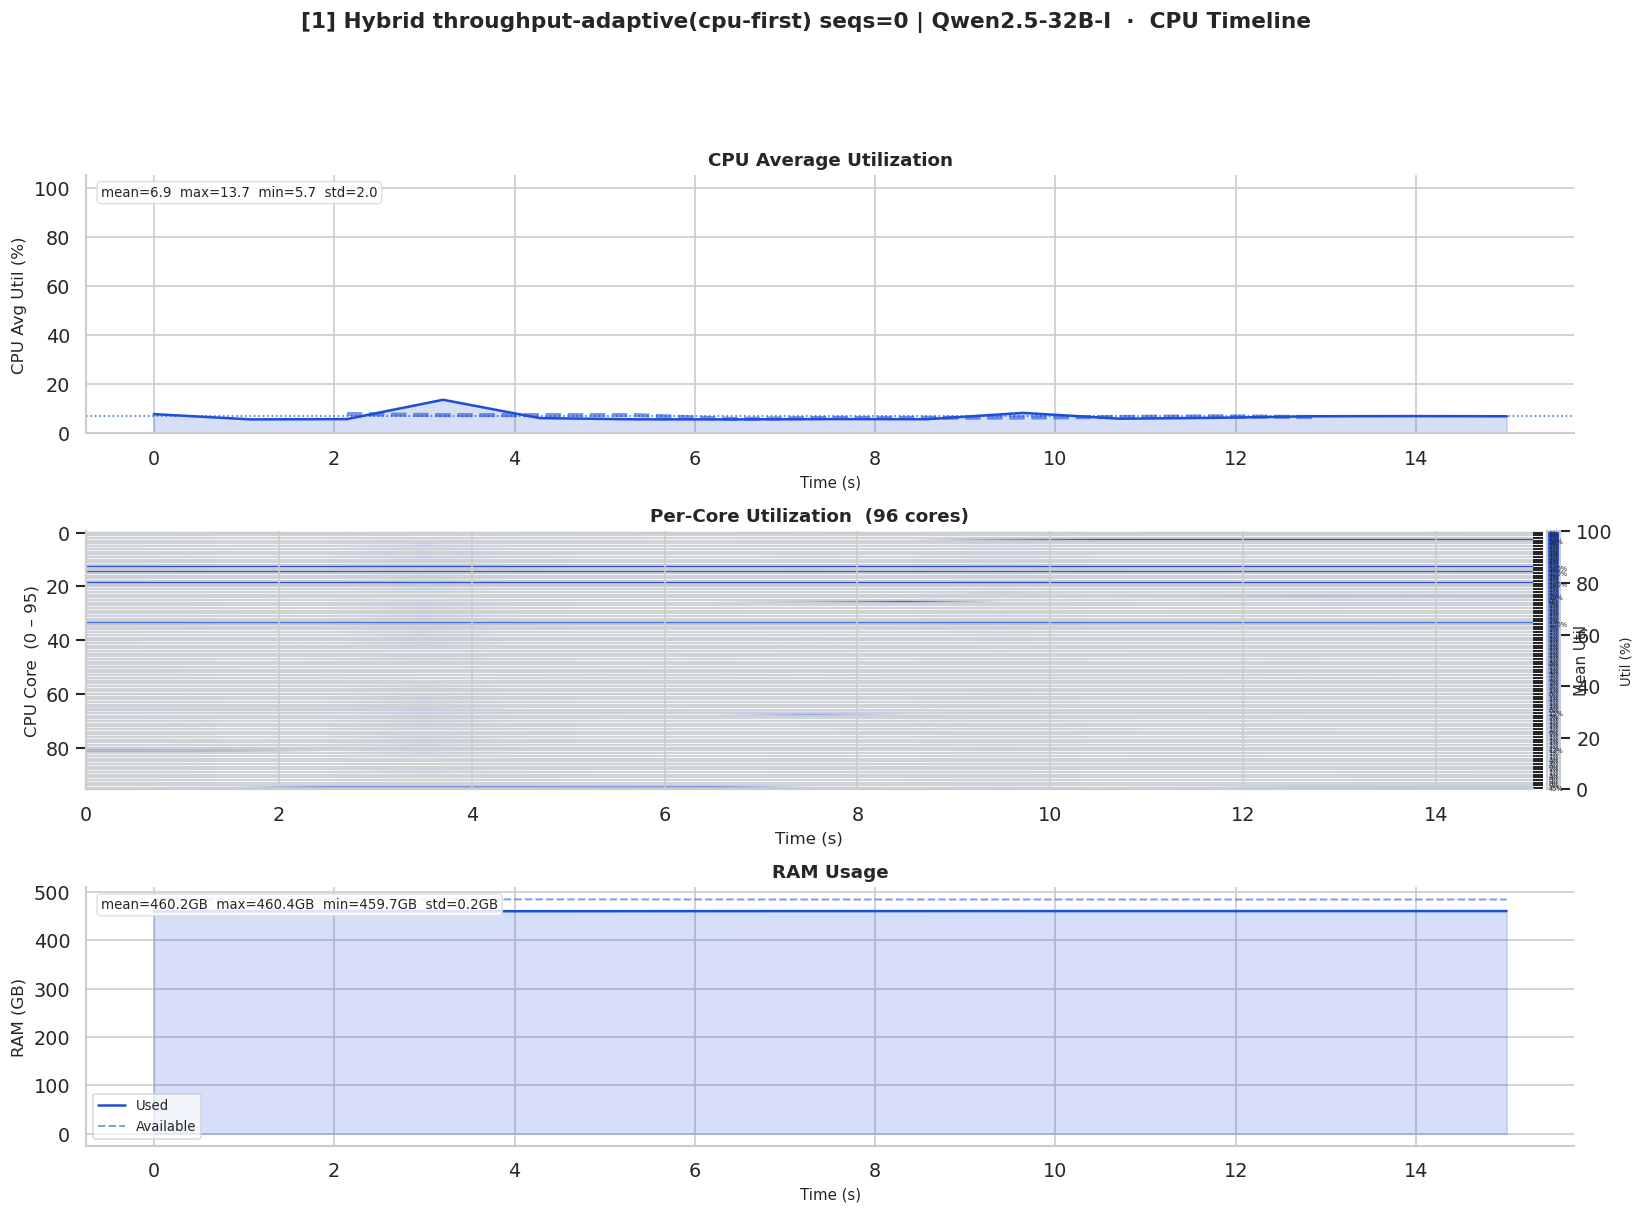

In [23]:
# ============================================================
#  Section 7b: Per-Run CPU Timeline — Avg Util / Per-Core Heatmap / RAM
#  (각 run 별로 CPU 평균 + 코어별 히트맵 + RAM 을 시간축으로 한눈에)
# ============================================================

for i, r in enumerate(runs):
    csv = r.get('cpu_csv')
    if csv is None:
        print(f'[{i}] No CPU CSV — skip')
        continue

    core_cols = [c for c in csv.columns if c.startswith('core') and c.endswith('_util_pct')]
    has_cores = bool(core_cols)
    has_ram   = 'cpu_mem_used_mb' in csv.columns

    n_rows = 1 + int(has_cores) + int(has_ram)
    fig, axes = plt.subplots(n_rows, 1, figsize=(16, 3.5 * n_rows),
                             gridspec_kw={'hspace': 0.38})
    if n_rows == 1:
        axes = [axes]

    ck    = run_color_key(r)
    color = PALETTE[ck]
    cmap  = CMAPS[ck]
    t     = csv['elapsed_s']
    label = make_label(r)

    fig.suptitle(f'[{i}] {label[:60]}  ·  CPU Timeline',
                 fontsize=13, fontweight='bold', y=1.01)

    ax_idx = 0

    # ── Row 0: CPU avg utilization ────────────────────────────
    ax = axes[ax_idx]; ax_idx += 1
    if 'cpu_avg_util_pct' in csv.columns:
        v = csv['cpu_avg_util_pct']
        ax.plot(t, v, color=color, lw=1.5, zorder=3)
        ax.fill_between(t, v, alpha=0.18, color=color, zorder=2)
        ax.plot(t, v.rolling(5, center=True).mean(),
                color=color, lw=2.5, ls='--', alpha=0.6, zorder=4)
        ax.axhline(v.mean(), color=color, lw=1, ls=':', alpha=0.8)
        vs = v.dropna()
        ax.text(0.01, 0.96,
                f'mean={vs.mean():.1f}  max={vs.max():.1f}  '
                f'min={vs.min():.1f}  std={vs.std():.1f}',
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ddd', alpha=0.85))
    ax.set_ylim(0, 105)
    ax.set_ylabel('CPU Avg Util (%)', fontsize=10)
    ax.set_title('CPU Average Utilization', fontsize=11, fontweight='semibold')
    ax.set_xlabel('Time (s)', fontsize=9)

    # ── Row 1: per-core heatmap ───────────────────────────────
    if has_cores:
        ax = axes[ax_idx]; ax_idx += 1
        n_cores = len(core_cols)
        data = csv[core_cols].values.T          # shape: (n_cores, n_samples)
        t0, t1 = float(t.iloc[0]), float(t.iloc[-1])
        im = ax.imshow(data, aspect='auto', cmap=cmap,
                       vmin=0, vmax=100, interpolation='bilinear',
                       extent=[t0, t1, n_cores - 0.5, -0.5])
        cb = plt.colorbar(im, ax=ax, fraction=0.018, pad=0.01)
        cb.set_label('Util (%)', fontsize=8)
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel(f'CPU Core  (0 – {n_cores - 1})', fontsize=10)
        ax.set_title(f'Per-Core Utilization  ({n_cores} cores)',
                     fontsize=11, fontweight='semibold')
        # mean% annotation per core on right margin
        mean_per_core = csv[core_cols].mean().values
        ax2 = ax.twinx()
        ax2.set_ylim(ax.get_ylim())
        ax2.set_yticks(range(n_cores))
        ax2.set_yticklabels([f'{v:.0f}%' for v in mean_per_core],
                            fontsize=max(4, 8 - n_cores // 10))
        ax2.set_ylabel('Mean Util', fontsize=9)

    # ── Row 2: RAM usage ─────────────────────────────────────
    if has_ram:
        ax = axes[ax_idx]; ax_idx += 1
        used_gb = csv['cpu_mem_used_mb'] / 1024
        ax.plot(t, used_gb, color=color, lw=1.5, label='Used', zorder=3)
        ax.fill_between(t, used_gb, alpha=0.18, color=color, zorder=2)
        if 'cpu_mem_avail_mb' in csv.columns:
            avail_gb = csv['cpu_mem_avail_mb'] / 1024
            ax.plot(t, avail_gb, color=color, lw=1.2, ls='--', alpha=0.55,
                    label='Available', zorder=3)
        m = used_gb.dropna()
        ax.text(0.01, 0.96,
                f'mean={m.mean():.1f}GB  max={m.max():.1f}GB  '
                f'min={m.min():.1f}GB  std={m.std():.1f}GB',
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ddd', alpha=0.85))
        ax.set_ylabel('RAM (GB)', fontsize=10)
        ax.set_title('RAM Usage', fontsize=11, fontweight='semibold')
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.legend(fontsize=8, framealpha=0.7)

    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()

In [24]:
# ============================================================
#  Section 8: System Info per Run
# ============================================================

tbl_style = [
    {'selector':'th','props':[('background-color','#2d4a7a'),('color','white'),
                              ('font-size','12px'),('padding','5px 10px')]},
    {'selector':'tr:nth-child(even)','props':[('background-color','#f5f8ff')]},
    {'selector':'td','props':[('font-size','12px'),('padding','4px 10px')]},
]

for i, r in enumerate(runs):
    si = r.get('sysinfo', {})
    hc = si.get('hybrid_config', {})
    cpu = si.get('cpu', {})
    gpu_devs = si.get('gpu', {}).get('devices', [{}])
    gpu_name = gpu_devs[0].get('name', '-') if gpu_devs else '-'
    sw = si.get('software', {})

    info_rows = [
        ('Mode', r.get('mode', '?')),
        ('CPU', cpu.get('model_name', '-')),
        ('GPU', gpu_name),
        ('vLLM', sw.get('vllm_version', '-')),
    ]
    if hc:
        s = hc.get('routing_strategy', '?')
        p = hc.get('routing_priority', '?')
        info_rows += [
            ('Routing', s if s == 'round-robin' else f'{s} ({p})'),
            ('CPU Max Seqs', hc.get('cpu_max_seqs', '?')),
            ('NUMA Aware', hc.get('numa_aware', '?')),
        ]

    df = pd.DataFrame(info_rows, columns=['Item','Value']).set_index('Item')
    display(df.style.set_table_styles(tbl_style)
            .set_caption(f'<b>[{i}] {make_label(r)}</b>'))

,Value
Item,
Mode,gpu_only
CPU,Intel(R) Xeon(R) Platinum 8480+
GPU,NVIDIA H100 80GB HBM3
vLLM,0.1.dev8475+g78fa48cb8
Routing,throughput-adaptive (cpu-first)
CPU Max Seqs,0
NUMA Aware,true


,Value
Item,
Mode,hybrid
CPU,Intel(R) Xeon(R) Platinum 8480+
GPU,NVIDIA H100 80GB HBM3
vLLM,0.1.dev8475+g78fa48cb8
Routing,throughput-adaptive (cpu-first)
CPU Max Seqs,0
NUMA Aware,true
